# 📉 Customer Churn Prediction — Code Walkthrough
Lean, code-first version. See `notebook.ipynb` for the full explanations.

## 1-2. Define & Collect — Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv("data/train-data.csv")
df.shape

(440833, 12)

## 3. Clean

In [2]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [3]:
df = df.dropna().drop(columns=["CustomerID"])

## 4. Explore (EDA)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  str    
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  str    
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), str(3)
memory usage: 40.4 MB


In [5]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df["Churn"].value_counts(normalize=True) * 100

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

In [7]:
churn_by_contract = df.groupby("Contract Length")["Churn"].mean() * 100
churn_by_gender = df.groupby("Gender")["Churn"].mean() * 100
churn_by_contract, churn_by_gender

(Contract Length
 Annual        46.076141
 Monthly      100.000000
 Quarterly     46.025605
 Name: Churn, dtype: float64,
 Gender
 Female    66.669115
 Male      49.126880
 Name: Churn, dtype: float64)

In [8]:
numeric_df = df.select_dtypes(include="number")
numeric_df.corr()["Churn"].sort_values(ascending=False)

Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
Name: Churn, dtype: float64

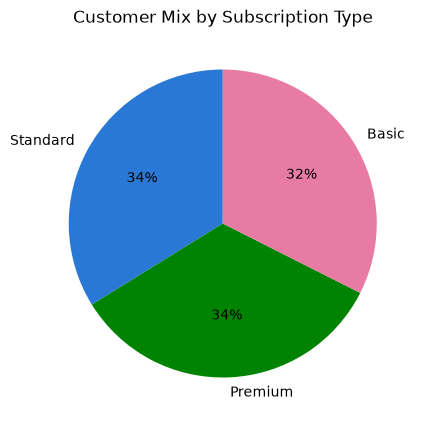

In [9]:
subscription_counts = df["Subscription Type"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    subscription_counts.values,
    labels=subscription_counts.index,
    autopct="%1.0f%%",
    colors=["#2a78d6", "#008300", "#e87ba4"],
    startangle=90,
)
plt.title("Customer Mix by Subscription Type")
plt.show()

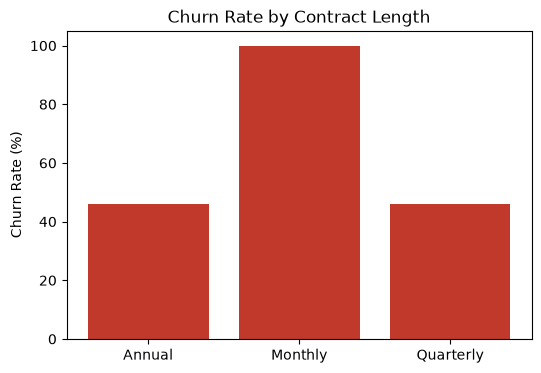

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(churn_by_contract.index, churn_by_contract.values, color="#c0392b")
plt.title("Churn Rate by Contract Length")
plt.ylabel("Churn Rate (%)")
plt.show()

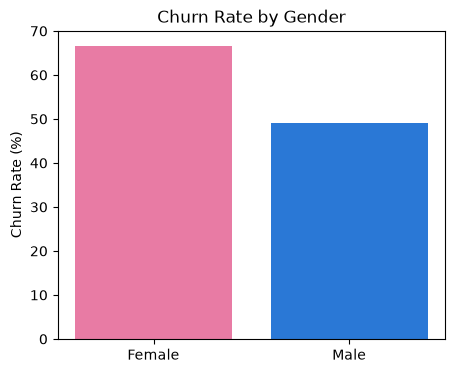

In [11]:
plt.figure(figsize=(5, 4))
plt.bar(churn_by_gender.index, churn_by_gender.values, color=["#e87ba4", "#2a78d6"])
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
plt.show()

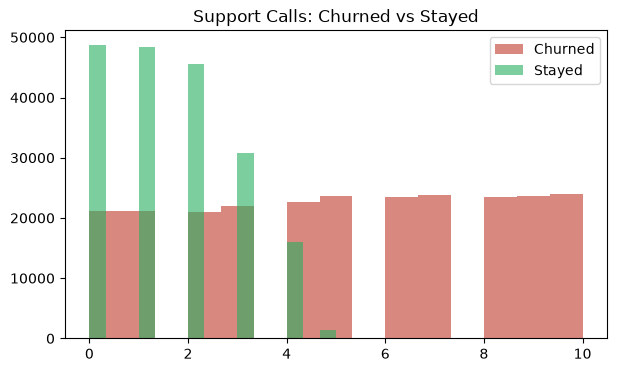

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(df[df["Churn"] == 1]["Support Calls"], bins=15, alpha=0.6, label="Churned", color="#c0392b")
plt.hist(df[df["Churn"] == 0]["Support Calls"], bins=15, alpha=0.6, label="Stayed", color="#27ae60")
plt.title("Support Calls: Churned vs Stayed")
plt.legend()
plt.show()

## 5. Model — Prepare Data (Encoding & Feature Engineering)

In [13]:
df_encoded = pd.get_dummies(df, columns=["Gender", "Subscription Type", "Contract Length"], drop_first=True)
df_encoded["Spend_Per_Tenure"] = df_encoded["Total Spend"] / (df_encoded["Tenure"] + 1)
df_encoded.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Spend_Per_Tenure
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False,23.300000
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False,11.140000
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True,12.333333
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False,10.153846
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False,18.696970


## 5. Model — Select & Train

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_reg = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)

## 6. Evaluate

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

log_reg_pred = log_reg.predict(X_val_scaled)
rf_pred = random_forest.predict(X_val)

pd.DataFrame({
    "Logistic Regression": [accuracy_score(y_val, log_reg_pred), precision_score(y_val, log_reg_pred),
                             recall_score(y_val, log_reg_pred), f1_score(y_val, log_reg_pred)],
    "Random Forest": [accuracy_score(y_val, rf_pred), precision_score(y_val, rf_pred),
                       recall_score(y_val, rf_pred), f1_score(y_val, rf_pred)],
}, index=["Accuracy", "Precision", "Recall", "F1 Score"]).round(4)

,Logistic Regression,Random Forest
Accuracy,0.8936,0.9996
Precision,0.9235,0.9999
Recall,0.8858,0.9993
F1 Score,0.9043,0.9996


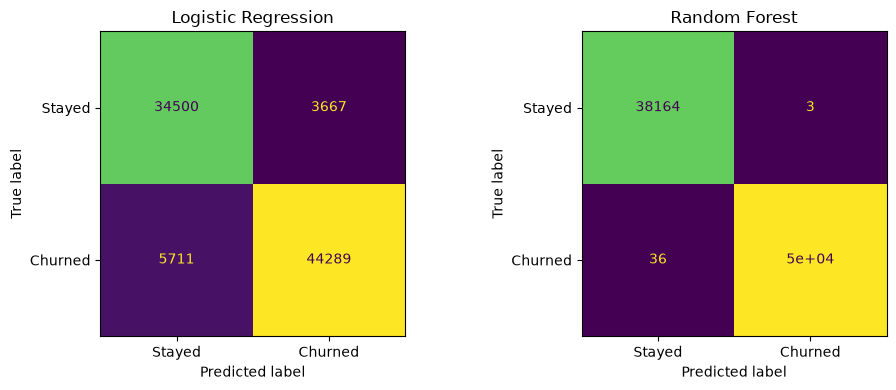

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_val, log_reg_pred, display_labels=["Stayed", "Churned"], ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_val, rf_pred, display_labels=["Stayed", "Churned"], ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

## 7. Deploy — Save & Serve

In [17]:
joblib.dump(random_forest, "churn_model.joblib")
FEATURE_COLUMNS = X_train.columns.tolist()

def predict_churn(customer, model=random_forest, columns=FEATURE_COLUMNS):
    row = pd.DataFrame([customer])
    row["Spend_Per_Tenure"] = row["Total Spend"] / (row["Tenure"] + 1)
    row = pd.get_dummies(row, columns=["Gender", "Subscription Type", "Contract Length"])
    row = row.reindex(columns=columns, fill_value=0)
    prediction = model.predict(row)[0]
    probability = model.predict_proba(row)[0][1]
    return f"{'Churn' if prediction == 1 else 'Stay'} (probability: {probability:.1%})"

sample_customer = {
    "Age": 42, "Gender": "Male", "Tenure": 3, "Usage Frequency": 2,
    "Support Calls": 9, "Payment Delay": 20, "Subscription Type": "Basic",
    "Contract Length": "Monthly", "Total Spend": 150, "Last Interaction": 28,
}
predict_churn(sample_customer)

'Churn (probability: 100.0%)'

## 7. Deploy — Monitor
Check the model on a genuinely separate file (`test-data.csv`) — never trust validation score alone.

In [18]:
test_df = pd.read_csv("data/test-data.csv").dropna().drop(columns=["CustomerID"])
test_df["Spend_Per_Tenure"] = test_df["Total Spend"] / (test_df["Tenure"] + 1)
test_df_encoded = pd.get_dummies(test_df, columns=["Gender", "Subscription Type", "Contract Length"])

X_test = test_df_encoded.drop(columns=["Churn"]).reindex(columns=FEATURE_COLUMNS, fill_value=0)
y_test = test_df_encoded["Churn"].astype(int)
test_pred = random_forest.predict(X_test)

print(f"Validation accuracy: {accuracy_score(y_val, rf_pred):.2%}")
print(f"Holdout accuracy (test-data.csv): {accuracy_score(y_test, test_pred):.2%}")

Validation accuracy: 99.96%
Holdout accuracy (test-data.csv): 50.36%
